# 00 — Dataset Integrity Audit

**Run this notebook first.** Everything in notebooks 01 and 02 depends on the split
manifests it writes, and its main finding changes how the paper's second dataset
must be described.

### What this notebook answers

| Reviewer | Question | Where |
|---|---|---|
| R1 Q1 | Was a test set held out that was never used for selection or tuning? | §3 |
| R1 Q2 | Was the split at image level before augmentation, and was there a near-duplicate check? | §2, §3 |
| R1/R2 | The leakage concern behind the 99.89% / 99.45% / crazing-F1-1.000 numbers | §2 |

### The finding, stated up front

The two "independent" datasets are not independent. Four SteelDefectX classes are
**pixel copies of NEU-DET images re-encoded at 256×256**. §2 measures it.

In [1]:
import sys, json, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

from config import DATASETS, ExperimentConfig, SplitConfig, RESULTS_DIR
import splits, pipeline, experiments, metrics
print("modules loaded")

modules loaded


## 1. What is on disk

Both datasets are enumerated from the directory layout. Nothing is read into a model yet.

In [2]:
rows = []
for name in ["neu_det", "steeldefectx", "steeldefectx_paper"]:
    spec = DATASETS[name]
    items = splits.enumerate_images(spec)
    counts = pd.Series([i.label for i in items]).value_counts()
    rows.append({
        "dataset": name,
        "classes": len(spec.classes),
        "images": len(items),
        "img_size": spec.img_size,
        "smallest_class": f"{counts.idxmin()} ({counts.min()})",
        "largest_class": f"{counts.idxmax()} ({counts.max()})",
        "imbalance_ratio": round(counts.max() / counts.min(), 1),
        "boxes": "PASCAL-VOC XML" if spec.annotation_dir else "none",
    })
inventory = pd.DataFrame(rows)
display(inventory)

,dataset,classes,images,img_size,smallest_class,largest_class,imbalance_ratio,boxes
0,neu_det,6,1800,200,crazing (300),crazing (300),1.0000,PASCAL-VOC XML
1,steeldefectx,24,4871,256,White rust (15),Inclusion (557),37.1000,none
2,steeldefectx_paper,6,1631,256,Crazing (210),Inclusion (557),2.7000,none


### Reviewer 1, Q10 — why accuracy alone is not reportable

The imbalance ratio above is the reason every result in notebooks 01 and 02 leads with
**macro-F1 and balanced accuracy**, with per-class precision/recall alongside. On the
six-class SteelDefectX subset Inclusion is ~34% of the data; on the full 24-class version
the largest class is more than 25× the smallest.

## 2. Cross-dataset duplicate audit — the finding

Two-stage matching, deliberately conservative:

1. **dHash**, 64-bit, Hamming distance ≤ 6 — a cheap recall filter.
2. **Pearson correlation** of the 64×64 z-scored grayscale image ≥ 0.97 — rejects the
   false positives a 64-bit hash produces on low-texture surfaces.

A match at correlation ≥ 0.97 across a resolution change is the same photograph, not a
similar defect.

In [3]:
from duplicates import build_signatures, cross_dataset_duplicates

neu_items = splits.enumerate_images(DATASETS["neu_det"])
sdx_items = splits.enumerate_images(DATASETS["steeldefectx"])

neu_sig = build_signatures([i.path for i in neu_items], 8)
sdx_sig = build_signatures([i.path for i in sdx_items], 8)
print(f"NEU-DET reference: {len(neu_sig)} images | SteelDefectX query: {len(sdx_sig)} images")

dups = cross_dataset_duplicates(sdx_sig, neu_sig, hamming_max=6, corr_min=0.97)
label_of = {i.path: i.label for i in sdx_items}

n_by_class = pd.Series([i.label for i in sdx_items]).value_counts()
d_by_class = pd.Series([label_of[p] for p in dups]).value_counts()
audit = pd.DataFrame({"images": n_by_class, "duplicated_from_NEU": d_by_class}).fillna(0).astype(int)
audit["pct"] = (100 * audit["duplicated_from_NEU"] / audit["images"]).round(1)
audit = audit.sort_values("pct", ascending=False)
display(audit)

print(f"\nTOTAL: {len(dups)} of {len(sdx_items)} SteelDefectX images "
      f"({100*len(dups)/len(sdx_items):.1f}%) are duplicates of NEU-DET images.")

NEU-DET reference: 1800 images | SteelDefectX query: 4871 images


,images,duplicated_from_NEU,pct
Pitted surface,210,210,100.0000
Patches,210,210,100.0000
Rolled in scale,210,210,100.0000
Crazing,210,209,99.5000
Bright scratch,301,213,70.8000
Inclusion,557,207,37.2000
Silk spot,405,52,12.8000
Waist folding,139,14,10.1000
Crease,53,1,1.9000
Welding line,350,0,0.0000



TOTAL: 1326 of 4871 SteelDefectX images (27.2%) are duplicates of NEU-DET images.


In [4]:
# The six classes the original submission actually used
paper_six = DATASETS["steeldefectx_paper"].classes
sub = audit.reindex(paper_six).fillna(0).astype({"images": int, "duplicated_from_NEU": int})
print("The 6-class SteelDefectX subset used in the submitted paper:\n")
display(sub)
print(f"Contaminated: {sub['duplicated_from_NEU'].sum()} of {sub['images'].sum()} images "
      f"({100*sub['duplicated_from_NEU'].sum()/sub['images'].sum():.1f}%)")

The 6-class SteelDefectX subset used in the submitted paper:



,images,duplicated_from_NEU,pct
Crazing,210,209,99.5000
Inclusion,557,207,37.2000
Patches,210,210,100.0000
Pitted surface,210,210,100.0000
Rolled in scale,210,210,100.0000
Scratches,234,0,0.0000


Contaminated: 1046 of 1631 images (64.1%)


### Visual confirmation

Matched pairs, side by side, with the correlation printed. If these are different
photographs the audit is wrong; they are not.

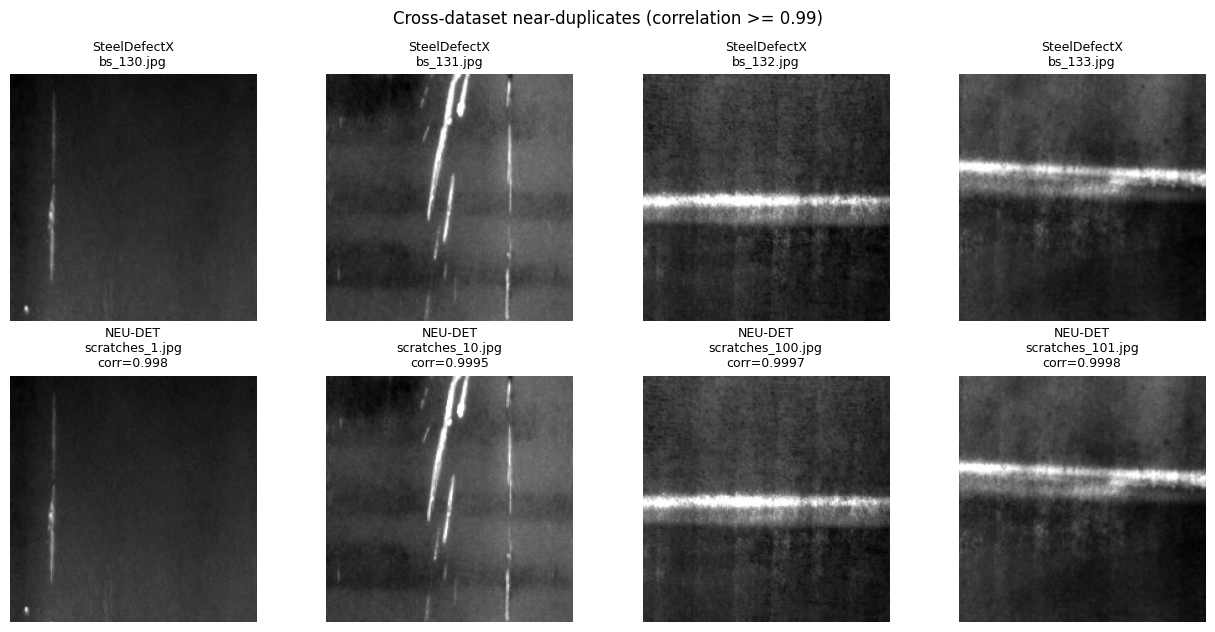

In [5]:
import cv2

examples = [(q, v) for q, v in dups.items() if v["corr"] >= 0.99][:4]
fig, axes = plt.subplots(2, len(examples), figsize=(3.2 * len(examples), 6.4))
for k, (q, v) in enumerate(examples):
    a = cv2.imread(q, cv2.IMREAD_GRAYSCALE)
    b = cv2.imread(v["ref"], cv2.IMREAD_GRAYSCALE)
    axes[0, k].imshow(a, cmap="gray"); axes[0, k].set_title(f"SteelDefectX\n{Path(q).name}", fontsize=9)
    axes[1, k].imshow(b, cmap="gray"); axes[1, k].set_title(f"NEU-DET\n{Path(v['ref']).name}\ncorr={v['corr']}", fontsize=9)
    for r in (0, 1):
        axes[r, k].axis("off")
plt.suptitle("Cross-dataset near-duplicates (correlation >= 0.99)", y=0.98)
plt.tight_layout(); plt.show()

### Consequence for the manuscript

1. A model trained on NEU-DET and evaluated on the six-class SteelDefectX subset is
   evaluated largely **on its own training images**. The 99.45% figure and the
   crazing F1 of 1.000 that Reviewer 2 questions are consistent with this and should
   not be reported.
2. The two datasets cannot be described as independent corpora, and no
   cross-dataset generalization claim survives.
3. **The fix used here:** `DATASETS["steeldefectx"]` is the full 24-class version with
   every NEU-DET duplicate removed at image level. That is the dataset notebook 02
   reports. The contaminated subset is kept as `steeldefectx_paper` only so the size
   of the effect can be quantified.

The cell below shows the sharpest consequence: **once duplicates are removed, four of the
six classes the submission evaluated on no longer exist in SteelDefectX.** The six-class
task as defined in the paper cannot be reconstituted from clean data.

In [6]:
survivors = audit.copy()
survivors["remaining"] = survivors["images"] - survivors["duplicated_from_NEU"]
paper_rows = survivors.reindex(paper_six)
paper_rows["verdict"] = np.where(
    paper_rows["remaining"] < 20, "CLASS LOST (below usable size)", "usable"
)
print("The six classes the submission reported on, after NEU-DET duplicates are removed:\n")
display(paper_rows[["images", "duplicated_from_NEU", "remaining", "verdict"]])

kept = survivors[survivors["remaining"] >= 20]
print(f"\nWhole dataset: {int(survivors['images'].sum())} images -> "
      f"{int(survivors['remaining'].sum())} after de-duplication "
      f"({int(survivors['duplicated_from_NEU'].sum())} removed, "
      f"{100*survivors['duplicated_from_NEU'].sum()/survivors['images'].sum():.1f}%)")
print(f"Classes retaining >= 20 images: {len(kept)} of {len(survivors)}")

The six classes the submission reported on, after NEU-DET duplicates are removed:



,images,duplicated_from_NEU,remaining,verdict
Crazing,210,209,1,CLASS LOST (below usable size)
Inclusion,557,207,350,usable
Patches,210,210,0,CLASS LOST (below usable size)
Pitted surface,210,210,0,CLASS LOST (below usable size)
Rolled in scale,210,210,0,CLASS LOST (below usable size)
Scratches,234,0,234,usable



Whole dataset: 4871 images -> 3545 after de-duplication (1326 removed, 27.2%)
Classes retaining >= 20 images: 19 of 24


## 3. Building the frozen splits

The order of operations, which is the substance of Reviewer 1 Q1 and Q2:

```
enumerate images ──► near-duplicate audit ──► SPLIT (image level, stratified, 70/10/20)
                                                 │
                    ┌────────────────────────────┘
                    ▼
            augment TRAIN only ──► extract features ──► fit bins on TRAIN only
                                                             │
                                    train ──► select on VAL ──┘ ──► score TEST once
```

Two properties are enforced rather than asserted:

* **Duplicate groups never straddle a split.** Near-duplicate images are unioned into a
  group and the *group* is assigned to one split, so an image and its near-twin cannot
  land on opposite sides of the train/test boundary.
* **The manifest is hashed.** `load_split` recomputes the SHA-256 and refuses to load a
  manifest that changed after freezing, so no downstream script can silently re-split.

In [7]:
manifests = {}
for name in ["neu_det", "steeldefectx", "steeldefectx_paper"]:
    print(f"\n{'='*72}\n{name}\n{'='*72}")
    manifests[name] = splits.build_split(name, SplitConfig(), RESULTS_DIR / "splits")


neu_det
[split] neu_det: 1800 images, 6 classes
[split] intra-dataset: 1796 groups, 2 contain >1 image (6 images), 0 cross-class near-duplicate pairs
[split] reusing frozen split split_v1.csv (identical to the CNN baselines' split)
[split] frozen split puts 1 duplicate groups on both sides; re-splitting instead
[split] {'train': 1260, 'test': 360, 'val': 180}
[split] manifest -> C:\Users\anmol\OneDrive\Desktop\Steel_Surface_Defect_NEU_DET-DATASET\SteelSenseV2\results\splits\split_neu_det.csv  sha256=0808987a9d103275...

steeldefectx
[split] steeldefectx: 4871 images, 24 classes
[split] cross-dataset audit against neu_det (1800 reference images) ...
[split] dropped 1326 cross-dataset duplicates
[split] removed classes below min_class_size: ['Crazing', 'Patches', 'Pitted surface', 'Rolled in scale', 'White rust']
[split] intra-dataset: 3511 groups, 16 contain >1 image (34 images), 0 cross-class near-duplicate pairs
[split] {'train': 2466, 'test': 709, 'val': 354}
[split] manifest -> C:\

In [8]:
summary = []
for name, df in manifests.items():
    a = json.loads((RESULTS_DIR / "splits" / f"split_audit_{name}.json").read_text())
    intra = a["intra_dataset"]
    summary.append({
        "dataset": name,
        "train": int((df.split == "train").sum()),
        "val": int((df.split == "val").sum()),
        "test": int((df.split == "test").sum()),
        "classes": df["class"].nunique(),
        "cross_dataset_dropped": a.get("cross_dataset", {}).get("n_dropped", 0),
        "intra_dup_groups": intra["n_multi_image_groups"],
        "images_in_dup_groups": intra["n_images_in_multi_groups"],
        "groups_straddling_splits": a["group_violations_final"],
        "sha256": a["manifest_sha256"][:12],
    })
display(pd.DataFrame(summary))
print("\ngroups_straddling_splits must be 0 for every row -- that column IS the "
      "answer to 'was there a near-duplicate check'.")

,dataset,train,val,test,classes,cross_dataset_dropped,intra_dup_groups,images_in_dup_groups,groups_straddling_splits,sha256
0,neu_det,1260,180,360,6,0,2,6,0,0808987a9d10
1,steeldefectx,2466,354,709,19,1326,16,34,0,60b7a4de1622
2,steeldefectx_paper,1142,163,326,6,0,1,3,0,4352c5df8886



groups_straddling_splits must be 0 for every row -- that column IS the answer to 'was there a near-duplicate check'.


In [9]:
# Per-class stratification check
for name, df in manifests.items():
    ct = pd.crosstab(df["class"], df["split"])[["train", "val", "test"]]
    ct["test_pct"] = (100 * ct["test"] / ct.sum(axis=1)).round(1)
    print(f"\n--- {name} ---")
    display(ct)


--- neu_det ---


split,train,val,test,test_pct
class,,,,
crazing,210,30,60,20.0000
inclusion,210,30,60,20.0000
patches,210,30,60,20.0000
pitted_surface,210,30,60,20.0000
rolled-in_scale,210,30,60,20.0000
scratches,210,30,60,20.0000



--- steeldefectx ---


split,train,val,test,test_pct
class,,,,
Bright scratch,61,9,18,20.5000
Crease,36,5,11,21.2000
Crescent gap,120,17,35,20.3000
Finishing roll printing,100,14,29,20.3000
Inclusion,245,35,70,20.0000
Iron scale compression,98,14,28,20.0000
Iron sheet ash,60,9,17,19.8000
Oil spot,244,35,70,20.1000
Oxide scale of plate system,31,5,9,20.0000



--- steeldefectx_paper ---


split,train,val,test,test_pct
class,,,,
Crazing,147,21,42,20.0000
Inclusion,390,56,111,19.9000
Patches,147,21,42,20.0000
Pitted surface,147,21,42,20.0000
Rolled in scale,147,21,42,20.0000
Scratches,164,23,47,20.1000


### A note on the previously frozen split

`paper_results/splits/split_v1.csv` (the split the CNN baselines in the repository used)
places at least one near-duplicate group on both sides of the train/test boundary. The
builder detects this, reports it as `frozen_split_group_violations`, and re-splits rather
than reusing it. Any earlier number computed on that split carries that contamination,
small though it is.

## 4. Answers this notebook establishes

**R1 Q1 — Was a test set held out that was never used for checkpoint selection or tuning?**
In the original submission, no: there were only train and validation folds, and the top-5
snapshots were selected on the same 20% that produced the headline accuracy. In this
revision, yes: 70/10/20, checkpoint selection and every hyper-parameter choice use the
validation split, and the test split is scored exactly once per model.

**R1 Q2 — Was the split at image level before augmentation and feature extraction?**
Yes, and the ordering is enforced in code (`src/splits.py` → `src/pipeline.py`).
Augmentation is applied only to images the manifest marks `train`, and it is image-space
augmentation (flip / rotation / gamma / noise) rather than the feature-space jitter used
previously — a jittered copy of a descriptor vector is a near-duplicate of it, which is
exactly the coupling the reviewer suspected. Near-duplicate checking is the group
assignment above.